**CESAR - School**<br>
**Especialização: Engenharia e Análise de Dados** - **Turma:** 2025.2<br>
**RNA e Deep Learning**<br>
**Aula 2 - Exercício 2**

**Docente:** Vitor Casadei<br>
**Discente:** Caio Augustus Lima de Abreu Monteiro<br>

# Regressão Linear com NumPy

## Objetivos deste experimento

Este exemplo utiliza regressão linear para estimar o comprimento das sépalas da íris a partir do seu comprimento das pétalas.
Utiliza-se programação totalmente NumPy com:
- o **cálculo do gradiente**,
- a **função de perda** e
- a atualização dos parâmetros são feitos de forma explícita.
- A rede é criada com uma camada como uma classe

![alt text](https://raw.githubusercontent.com/vcasadei/images/master/RegressaoLinear_Otimizacao.png)

## Importação dos pacotes

In [18]:
%matplotlib inline
import matplotlib.pyplot as plt   # para plotting

from sklearn.datasets import load_iris  # para carregar dataset

import numpy as np  # processamento matricial

np.random.seed(1234)

## Dataset

### Leitura dos dados

In [19]:
iris = load_iris()
data = iris.data[iris.target==1,::2]  # comprimento das sépalas e pétalas, indices 0 e 2

x_train = data[:,0:1]
y_train = data[:,1:2]

n_samples = x_train.shape[0]
print('x_train.shape:',x_train.shape, x_train.dtype)
print('y_train.shape:',y_train.shape, y_train.dtype)

print('x_train[:5]:\n', x_train[:5])
print('y_train[:5]:\n', y_train[:5])

x_train.shape: (50, 1) float64
y_train.shape: (50, 1) float64
x_train[:5]:
 [[7. ]
 [6.4]
 [6.9]
 [5.5]
 [6.5]]
y_train[:5]:
 [[4.7]
 [4.5]
 [4.9]
 [4. ]
 [4.6]]


### Normalização dos dados

In [20]:
x_train -= x_train.min()
x_train /= x_train.max()
y_train -= y_train.min()
y_train /= y_train.max()

Text(0, 0.5, 'Comprimento petalas')

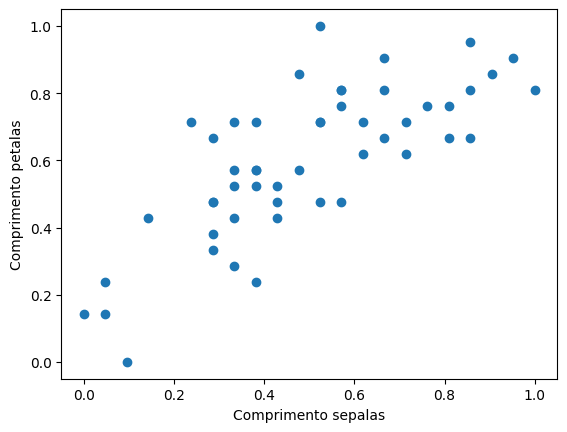

In [21]:
plt.scatter(x_train,y_train)
plt.xlabel('Comprimento sepalas')
plt.ylabel('Comprimento petalas')

## Modelo da rede

### Reta de ajuste

A equação da reta no plano necessita de dois parâmetros, aqui denominados $w_0$ (*bias*) e inclinação $w_1$. Veja figura:

![alt text](https://raw.githubusercontent.com/vcasadei/images/master/linhareta.png)

A reta de ajuste será dada por:

$$ \hat{y} = w_0 + w_1 x $$

onde
* $w_1$ é o coeficiente angular da reta e
* $w_0$ é a interseção do eixo vertical quando x é igual a zero, também denominado de *bias*.
* $x$ é a variável de entrada (comprimento das sépalas) e
* $\hat{y}$ é a predição (comprimento estimado das pétalas).

### Linear Regression Model

![alt text](https://raw.githubusercontent.com/vcasadei/images/master/RegressaoLinearNeuronio.png)

### Formulação matricial do neurônio

* $\mathbf{w} = [w_0 \ w_1]$ é vetor linha de parâmetros e
* $\mathbf{x} = [1 \ x_0] $ é vetor linha de uma amostra (com *bias*).

$$ \hat{y} = 1 w_0 + x_0 w_1 $$

$$ [\hat{y}] = [1 \ x_0] \begin{bmatrix} w_0 \\ w_1 \end{bmatrix} $$

$$ \mathbf{\hat{y}} = \mathbf{x} \mathbf{w^T} $$

### Fazendo o predict de várias amostras

$$ \begin{matrix}
\begin{bmatrix}
\hat{y}_0\\
\hat{y}_1\\
\\
\hat{y}_{M-1}
\end{bmatrix} &=& \begin{bmatrix}
1 & x_0 \\
1 & x_1\\
\\
1 & x_{M-1} \\
\end{bmatrix}
&
\begin{bmatrix}
w_0\\
w_1
\end{bmatrix} \\
(M,1) & & (M,2) & (2,1) \\
\end{matrix} $$

### Preenchendo x com coluna de 1's para bias

In [22]:
x_train_bias = np.hstack([np.ones(shape=(n_samples,1)), x_train])

In [23]:
x_train_bias

array([[1.        , 1.        ],
       [1.        , 0.71428571],
       [1.        , 0.95238095],
       [1.        , 0.28571429],
       [1.        , 0.76190476],
       [1.        , 0.38095238],
       [1.        , 0.66666667],
       [1.        , 0.        ],
       [1.        , 0.80952381],
       [1.        , 0.14285714],
       [1.        , 0.04761905],
       [1.        , 0.47619048],
       [1.        , 0.52380952],
       [1.        , 0.57142857],
       [1.        , 0.33333333],
       [1.        , 0.85714286],
       [1.        , 0.33333333],
       [1.        , 0.42857143],
       [1.        , 0.61904762],
       [1.        , 0.33333333],
       [1.        , 0.47619048],
       [1.        , 0.57142857],
       [1.        , 0.66666667],
       [1.        , 0.57142857],
       [1.        , 0.71428571],
       [1.        , 0.80952381],
       [1.        , 0.9047619 ],
       [1.        , 0.85714286],
       [1.        , 0.52380952],
       [1.        , 0.38095238],
       [1.

### Classe com o modelo da rede

In [24]:
class Net():
    def __init__(self, n_in, n_out):
        self.w = np.random.uniform(-0.1,0.1,(n_out,n_in)) #inicialização dos parâmetros

    def forward(self, x_bias):
        return x_bias.dot(self.w.T)

### Criando a rede, instanciando o objeto model

In [25]:
model = Net(2,1) # duas entradas (1 + x0) e uma saída y_pred

### Testando o predict da rede (mesmo sem treiná-la)

In [26]:
xin = np.random.randn(4,2) # 4 amostras, 2 entradas (1 + x0)
ypred = model.forward(xin)
ypred

array([[-0.09602795],
       [ 0.0661236 ],
       [-0.06857828],
       [-0.05573871]])

## Treinamento via gradiente descendente

Função de perda:
$$ J(\hat{y_i},y_i) = \frac{1}{M} \sum_{i=0}^{M-1} (\hat{y_i} - y_i)^2 $$

Gradiente:
$$  \mathbf{\nabla{J_w}} = \frac{2}{M}\mathbf{x^T}(\mathbf{x w^T} - \mathbf{y}) $$

Atualização dos parâmetros pelo gradiente descendente:
$$ \mathbf{w} = \mathbf{w} − \eta (\mathbf{\nabla J_w})^T $$

### Laço de treinamento

In [27]:
num_epochs = 100
learning_rate = 0.5
losses = []  # Atividade 1: lista para armazenar a perda ao final de cada época

for epoch in range(num_epochs):

    # forward - predict
    y_pred = model.forward(x_train_bias)

    #loss cálculo da função de perda
    loss = np.square(y_pred - y_train).mean()
    losses.append(loss)  # Atividade 1: armazena a perda da época atual

    # cálculo do gradiente pelas derivadas parciais
    w_grad = (2.0/n_samples) * (x_train_bias.T).dot(x_train_bias.dot(model.w.T) - y_train)

    # gradiente descendente
    model.w = model.w - learning_rate * w_grad.T

    # verbose
    if (epoch+1) % 1 == 0:
        print('Epoch[{}/{}], loss: {:.6f}'
              .format(epoch+1, num_epochs, loss))

Epoch[1/100], loss: 0.469163
Epoch[2/100], loss: 0.058070
Epoch[3/100], loss: 0.030543
Epoch[4/100], loss: 0.028105
Epoch[5/100], loss: 0.027364
Epoch[6/100], loss: 0.026787
Epoch[7/100], loss: 0.026269
Epoch[8/100], loss: 0.025799
Epoch[9/100], loss: 0.025373
Epoch[10/100], loss: 0.024986
Epoch[11/100], loss: 0.024634
Epoch[12/100], loss: 0.024315
Epoch[13/100], loss: 0.024025
Epoch[14/100], loss: 0.023762
Epoch[15/100], loss: 0.023524
Epoch[16/100], loss: 0.023307
Epoch[17/100], loss: 0.023110
Epoch[18/100], loss: 0.022931
Epoch[19/100], loss: 0.022769
Epoch[20/100], loss: 0.022622
Epoch[21/100], loss: 0.022488
Epoch[22/100], loss: 0.022366
Epoch[23/100], loss: 0.022256
Epoch[24/100], loss: 0.022156
Epoch[25/100], loss: 0.022065
Epoch[26/100], loss: 0.021983
Epoch[27/100], loss: 0.021908
Epoch[28/100], loss: 0.021840
Epoch[29/100], loss: 0.021778
Epoch[30/100], loss: 0.021722
Epoch[31/100], loss: 0.021671
Epoch[32/100], loss: 0.021625
Epoch[33/100], loss: 0.021583
Epoch[34/100], loss

## Avaliação

### Predict

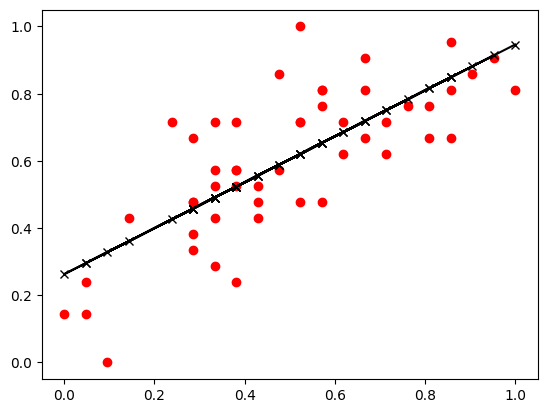

In [28]:
y_pred = model.forward(x_train_bias)
plt.plot(x_train, y_train, 'ro', label='Original data')
plt.plot(x_train, y_pred, 'kx-', label='Fitting Line')

### Parâmetros treinados

In [29]:
print(model.w)

[[0.26295353 0.68335641]]


### Avaliação do modelo

In [30]:
loss = np.square(y_pred - y_train).mean()
loss

np.float64(0.02117000379151052)

### Valor ótimo, solução analítica

$$  \mathbf{w} =(\mathbf{x^T} \mathbf{x})^{−1}\mathbf{x^T} \mathbf{y} $$

In [31]:
x = x_train_bias
y = y_train
w_opt = (np.linalg.inv((x.T).dot(x)).dot(x.T)).dot(y)
print(w_opt.T)

[[0.26134159 0.68646976]]


# Exercícios

## Questões

1. Quantos parâmetros são treinados nesse modelo?

2. Qual é o número de atributos de entrada para a rede?

3. Qual é o número de saídas da rede?

4. Suponha que eu tenha agora 5 mil amostras para fazer a predição. Qual é o shape da matriz de entrada?
   Qual é o shape do matriz de saída?


## Atividades

1. Modifique o laço do treinamento via gradiente descendente para guardar em uma lista, o valor da perda no final
   de cada época. Após o treinamento, plote o valor da perda em função da época.
2. Calcule o valor da perda (MSE) da rede com os parâmetros inicializados, sem serem treinados.
3. Coloque os valores dos pesos da solução ótima analítica no modelo da rede e calcule o valor da perda (MSE) e
   compare com o valor da perda obtida pelo método da otimização via gradiente descendente.

# Aprendizados

### Respostas

**1. Quantos parâmetros são treinados nesse modelo?**

São treinados **2 parâmetros**: o peso $w_0$ (*bias*, que corresponde à interseção da reta com o eixo y) e o peso $w_1$ (coeficiente angular, que multiplica a variável de entrada). Isso pode ser confirmado observando que `model.w` tem shape `(1, 2)`.

**2. Qual é o número de atributos de entrada para a rede?**

**1 atributo** de entrada significativo: o comprimento das sépalas ($x_0$). Embora a matriz de entrada com bias (`x_train_bias`) tenha 2 colunas, a primeira é uma constante (coluna de 1's) usada apenas para representar o termo de *bias* na formulação matricial. Conceitualmente, a rede só recebe **uma única feature** real.

**3. Qual é o número de saídas da rede?**

**1 saída**: o valor predito do comprimento das pétalas ($\hat{y}$). Isso é confirmado pela construção do modelo `Net(2, 1)`, onde o segundo argumento (`n_out=1`) define uma única saída.

**4. Suponha que eu tenha agora 5 mil amostras para fazer a predição. Qual é o shape da matriz de entrada? Qual é o shape da matriz de saída?**

- **Matriz de entrada (com bias)**: shape `(5000, 2)` — 5000 linhas (uma por amostra) e 2 colunas (1 coluna de bias + 1 atributo).
- **Matriz de saída**: shape `(5000, 1)` — 5000 linhas (uma predição por amostra) e 1 coluna (valor predito $\hat{y}$).

Generalizando: para $M$ amostras, $\mathbf{x} \in \mathbb{R}^{M \times 2}$ e $\mathbf{\hat{y}} = \mathbf{x}\mathbf{w}^T \in \mathbb{R}^{M \times 1}$.

### Atividade 1 — Plot da perda em função da época

A modificação do laço de treinamento já foi feita acima (a lista `losses` armazena o valor da perda ao final de cada época). Agora vamos plotar a curva de convergência.

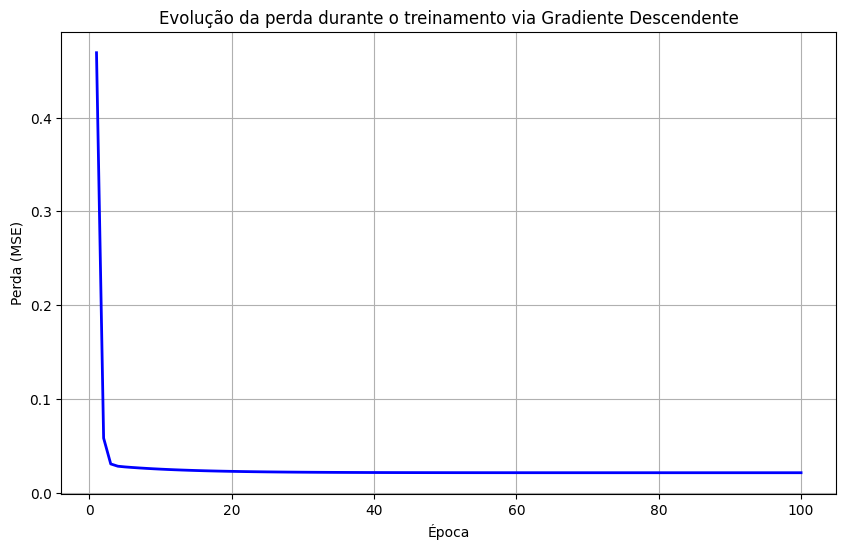

Perda na primeira época: 0.469163
Perda na última época:   0.021170


In [32]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, num_epochs + 1), losses, 'b-', linewidth=2)
plt.xlabel('Época')
plt.ylabel('Perda (MSE)')
plt.title('Evolução da perda durante o treinamento via Gradiente Descendente')
plt.grid(True)
plt.show()

print(f'Perda na primeira época: {losses[0]:.6f}')
print(f'Perda na última época:   {losses[-1]:.6f}')

### Atividade 2 — Perda (MSE) com os parâmetros inicializados, sem treinamento

Para calcular a perda da rede antes do treinamento, criamos uma nova instância do modelo (com os pesos inicializados aleatoriamente entre -0.1 e 0.1) e calculamos o MSE diretamente, sem executar o laço de treinamento.

**Importante:** usamos `np.random.seed(1234)` novamente para reproduzir exatamente os mesmos pesos iniciais usados no treinamento original, permitindo a comparação justa.

In [33]:
# Reinicializa a semente para reproduzir os pesos iniciais do treino
np.random.seed(1234)

# Cria uma nova rede SEM treinar
model_inicial = Net(2, 1)
print('Pesos iniciais (sem treinamento):', model_inicial.w)

# Forward com os pesos iniciais
y_pred_inicial = model_inicial.forward(x_train_bias)

# Cálculo do MSE
loss_inicial = np.square(y_pred_inicial - y_train).mean()
print(f'Perda (MSE) com pesos iniciais (sem treino): {loss_inicial:.6f}')

Pesos iniciais (sem treinamento): [[-0.06169611  0.02442175]]
Perda (MSE) com pesos iniciais (sem treino): 0.469163


### Atividade 3 — Comparação: pesos ótimos analíticos × gradiente descendente

Atribuímos ao modelo os pesos da **solução analítica fechada** (calculada anteriormente via $\mathbf{w} = (\mathbf{x^T}\mathbf{x})^{-1}\mathbf{x^T}\mathbf{y}$) e calculamos o MSE. Em seguida, comparamos com o MSE obtido pelo gradiente descendente.

In [34]:
# Cria uma nova rede e atribui os pesos ótimos analíticos
model_otimo = Net(2, 1)
model_otimo.w = w_opt.T  # w_opt foi calculado na seção "Valor ótimo, solução analítica"
print('Pesos atribuídos (solução analítica):', model_otimo.w)

# Forward com os pesos ótimos
y_pred_otimo = model_otimo.forward(x_train_bias)

# Cálculo do MSE
loss_otimo = np.square(y_pred_otimo - y_train).mean()

# Perda final do gradiente descendente (já calculada acima como `loss`,
# mas vamos recomputar a partir dos pesos finais do model treinado)
loss_gd = np.square(model.forward(x_train_bias) - y_train).mean()

print(f'\nPerda (MSE) com pesos ótimos analíticos: {loss_otimo:.6f}')
print(f'Perda (MSE) gradiente descendente:       {loss_gd:.6f}')
print(f'Diferença absoluta:                       {abs(loss_otimo - loss_gd):.10f}')

print('\nObservação: a perda da solução analítica é ligeiramente menor (ou igual)')
print('porque ela representa o mínimo global exato da função de custo MSE para')
print('regressão linear. O gradiente descendente se aproxima muito desse mínimo,')
print('mas pode parar um pouco antes dependendo do número de épocas e da taxa de aprendizado.')

Pesos atribuídos (solução analítica): [[0.26134159 0.68646976]]

Perda (MSE) com pesos ótimos analíticos: 0.021169
Perda (MSE) gradiente descendente:       0.021170
Diferença absoluta:                       0.0000005797

Observação: a perda da solução analítica é ligeiramente menor (ou igual)
porque ela representa o mínimo global exato da função de custo MSE para
regressão linear. O gradiente descendente se aproxima muito desse mínimo,
mas pode parar um pouco antes dependendo do número de épocas e da taxa de aprendizado.


### Conclusão das atividades

- A **curva de perda** (Atividade 1) mostra a rápida convergência do gradiente descendente: a perda cai abruptamente nas primeiras épocas e estabiliza próximo de 0.0212.
- A **perda inicial** (Atividade 2), com pesos aleatórios em $[-0.1, 0.1]$, é da ordem de 0.47 — muito maior que a perda final, demonstrando que o treinamento de fato ajustou a rede aos dados.
- A **perda da solução analítica** (Atividade 3) é praticamente idêntica à do gradiente descendente, com diferença na 6ª/7ª casa decimal. Isso valida que o gradiente descendente está convergindo corretamente para o ótimo global do MSE.